# UADAPy Demo

In [10]:
# Ensure imports work when running from examples/ directory
import sys
import os
if os.getcwd().endswith('examples'):
    sys.path.insert(0, os.path.abspath('..'))

## Distributions
UADAPy handles uncertainty through probability distributions. Therefore it's core is the **`Distribution`** class.

In [3]:
import numpy as np
from scipy import stats
from uadapy import Distribution

In [4]:
# wrap any distribution object in UADAPy's unified Distribution interface
dist = Distribution(stats.multivariate_normal(np.zeros(2)))

# get some summary statistics
print(f"mean = {dist.mean()}. total variance = {np.trace(dist.cov())}.")

# draw samples from the distribution
samples = dist.sample(10000)

# determine probability densities at specific locations 
densities = dist.pdf(samples)
print(f"peak location = {samples[np.argmax(densities)]}")

mean = [0. 0.]. total variance = 2.0.
peak location = [-0.01987277  0.00578399]


### Data to Distribution
Distributions can be estimated from observations easily via KDE

In [5]:
from sklearn import datasets

iris = datasets.load_iris()
dists = []
for species in range(3):
    species_data = iris['data'][iris['target'] == species]
    # estimate distribution from data points (KDE)
    dists.append(Distribution(species_data))
    print(f"iris {iris['target_names'][species]} mean: {dists[species].mean()}")

iris setosa mean: [5.006 3.428 1.462 0.246]
iris versicolor mean: [5.936 2.77  4.26  1.326]
iris virginica mean: [6.588 2.974 5.552 2.026]


## Visualizing distributions
UADAPy provides a convenient API to visualize distributions that usually requires lots of boilder plate code

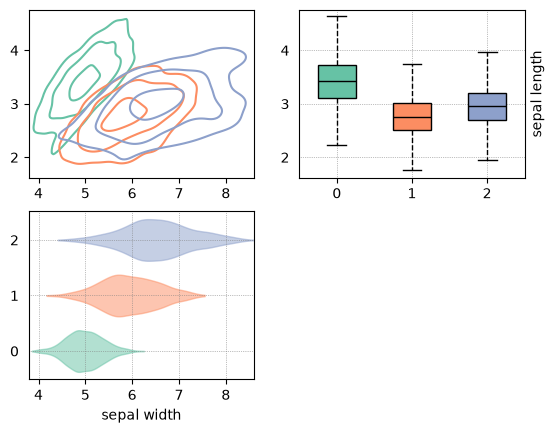

In [6]:
import matplotlib.pyplot as plt
from uadapy.plotting import plots_1d, plots_2d

# lets show sepal width and length distributions
fig, axs = plt.subplots(2,2)
axs[0,0].sharex(axs[1,0])
axs[0,0].sharey(axs[0,1])
axs[1,1].remove()
# labeling
axs[0,1].yaxis.set_label_position("right")
axs[0,1].set_ylabel('sepal length')
axs[1,0].set_xlabel('sepal width')

# we can estimate the respective marginal distributions (dropping petal width and length) 
sepal_dists = [Distribution(d.sample(1000)[:,0:2]) for d in dists]
# same for the single attribute distributions
sw_dists = [Distribution(d.sample(1000)[:,0]) for d in dists]
sl_dists = [Distribution(d.sample(1000)[:,1]) for d in dists]


plots_2d.plot_contour(sepal_dists, fig=fig, axs=axs[0,0]) # .25, .75, .95 quantile contours (highest density regions)
plots_1d.plot_1d_distribution(sl_dists, 1000, plot_types=['boxplot'], fig=fig, axs=axs[0,1])
plots_1d.plot_1d_distribution(sw_dists, 1000, plot_types=['violinplot'], fig=fig, axs=axs[1,0], vert=False)
fig;

## Uncertainty Aware Dimensionality Reduction
For high dimensional distributions, several dimensionality reduction methods that propagate uncertainty
can be employed.

*Note: UADAPy's dev team tries to integrate uncertainty-aware DR of our community whenever possible.*

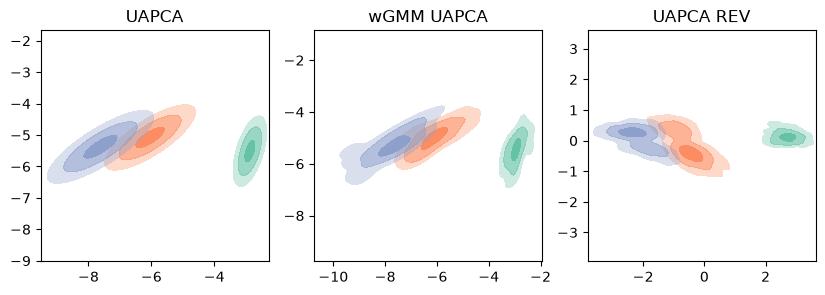

In [45]:
from uadapy.dr import uapca, uapca_revisited, vipurpca, wgmm_uapca, uamds
from uadapy.distributions import gmm_from_kde

# computing uncertainty-aware PCA
uapca_projections = uapca(dists, n_dims=2)

# computing weighted gaussian mixture model uaPCA
# for this we transform KDE to GMM
gmms = [Distribution(gmm_from_kde(d.kde)) for d in dists]
wgmm_projections = wgmm_uapca(gmms, n_dims=2)

# computing uncertainty-aware PCA REVISITED
# this technique yields samples from which we can estimate distributions
projected_samples = uapca_revisited(dists, n_dims=2, n_samples=1000)
uapca_r_projections = [Distribution(s) for s in projected_samples]

fig, axs = plt.subplots(1,3, figsize=(10,3))
axs[0].set_title('UAPCA')
plots_2d.plot_contour_bands(uapca_projections, fig=fig, axs=axs[0])
axs[1].set_title('wGMM UAPCA')
plots_2d.plot_contour_bands(wgmm_projections, fig=fig, axs=axs[1])
axs[2].set_title('UAPCA REV')
plots_2d.plot_contour_bands(uapca_r_projections, fig=fig, axs=axs[2])
for ax in axs:
    ax.set_aspect('equal', adjustable='datalim')
fig;

## Datasets

UADAPy provides datasets of multivariate distributions for your convenience.

In [ ]:
# TODO